# The Narrow-Parameter Problem in NPE + Importance Sampling
### A critical study based on Dingo-IS (Dax et al. 2023)

---

> **The forward KL loss is simultaneously the reason IS works (mass-covering) and the reason it fails for narrow parameters (forces over-broad approximations).**

We study this on controlled toy posteriors where ground truth is known.

## 1. Some warm-up

### 1.1 Why Forward KL enforces mass coverage

NPE minimizes the **forward KL divergence**:

$$\mathcal{L}_{\text{fKL}} = D_{KL}(p(\theta|d) \| q_\phi(\theta|d)) = \mathbb{E}_{p}\left[\log \frac{p(\theta|d)}{q_\phi(\theta|d)}\right]$$

We can see that:

$$D_{KL}(p \| q) = +\infty \iff \text{supp}(p) \not\subseteq \text{supp}(q)$$

The optimizer is **penalized infinitely** for missing any region of posterior mass. This guarantees $\text{supp}(p) \subseteq \text{supp}(q)$ at the optimum (the **mass-covering** or support inclusion property). This is essential for IS to give unbiased evidence estimates.

### 1.2 Impact on IS efficiency

Sample efficiency is related to KL divergence by:

$$\epsilon = \frac{n_{\text{eff}}}{n} \leq \exp\left(-D_{KL}(p \| q)\right)$$

When $q$ is too broad in the narrow dimension, we draw many samples $\theta_2$ far from $\mu(\theta_1)$, where $p(\theta_2|\theta_1,d) \approx 0$. These samples get near-zero importance weights, destroying efficiency:

$$w_i = \frac{p(d|\theta_i)p(\theta_i)}{q(\theta_i|d)} \approx 0 \quad \text{for } \theta_{2,i} \text{ far from } \mu(\theta_{1,i})$$

### 1.4 reverse KL

The **reverse KL** $D_{KL}(q \| p)$ has the opposite behavior — it is **mode-seeking**, preferring to concentrate $q$ on high-probability regions and ignoring tails. It would approximate narrow conditionals well but risks missing posterior modes entirely, violating the mass-coverage requirement for IS.

| Loss | Mass-covering | Narrow dim quality | IS unbiased |
|------|--------------|-------------------|-------------|
| Forward KL | ✓ guaranteed | ✗ over-broad | ✓ |
| Reverse KL | ✗ mode-seeking | ✗ fails as well | ✗ potentially |
| Synthetic marginalization (Dingo trick) | ✓ | ✓ (bypasses) | ✓ |

## 2. Setup and Imports

In [1]:
!pip install normflows torch matplotlib numpy scipy tqdm -q

In [ ]:
# pip install torch==2.9

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore') # :)

# Device setup — automatically uses GPU if available (Colab)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)

Using device: cuda
GPU: Tesla T4


## 3. Normalizing Flow Implementation

We implement a **conditional Real-NVP** (Dinh et al. 2017) as our normalizing flow $q_\phi(\theta|d)$.
The flow transforms a simple base distribution $z \sim \mathcal{N}(0, I)$ into the posterior via invertible transformations conditioned on observed data $d$.

In [3]:
class MLP(nn.Module):
    """Simple MLP used as coupling network inside the flow."""
    def __init__(self, in_dim, out_dim, hidden=128, context_dim=0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + context_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x, context=None):
        if context is not None:
            x = torch.cat([x, context], dim=-1)
        return self.net(x)


class AffineCouplingLayer(nn.Module):
    """
    Affine coupling layer: splits theta into two halves,
    transforms second half conditioned on first half + context d.
    """
    def __init__(self, dim, context_dim, mask, hidden=128):
        super().__init__()
        self.mask = mask  # boolean mask: True = passthrough
        d_in = mask.sum().item()
        d_out = (~mask).sum().item()
        self.scale_net = MLP(d_in, d_out, hidden, context_dim)
        self.translate_net = MLP(d_in, d_out, hidden, context_dim)

    def forward(self, x, context=None):
        """Forward pass: x -> z (for density evaluation)"""
        x0 = x[:, self.mask]       # passthrough dims
        x1 = x[:, ~self.mask]      # transformed dims
        s = torch.tanh(self.scale_net(x0, context))
        t = self.translate_net(x0, context)
        z1 = x1 * torch.exp(s) + t
        z = x.clone()
        z[:, ~self.mask] = z1
        log_det = s.sum(dim=-1)
        return z, log_det

    def inverse(self, z, context=None):
        """Inverse pass: z -> x (for sampling)"""
        z0 = z[:, self.mask]
        z1 = z[:, ~self.mask]
        s = torch.tanh(self.scale_net(z0, context))
        t = self.translate_net(z0, context)
        x1 = (z1 - t) * torch.exp(-s)
        x = z.clone()
        x[:, ~self.mask] = x1
        return x


class ConditionalNormalizingFlow(nn.Module):
    """
    Conditional normalizing flow q(theta | d).
    Stack of affine coupling layers with alternating masks.
    """
    def __init__(self, dim, context_dim, n_layers=8, hidden=128):
        super().__init__()
        self.dim = dim
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            # Alternate mask: even layers mask first half, odd layers mask second half
            mask = torch.zeros(dim, dtype=torch.bool)
            mask[:(dim // 2) if i % 2 == 0 else (dim - dim // 2)] = True
            self.layers.append(AffineCouplingLayer(dim, context_dim, mask, hidden))
        # Learnable base distribution (standard normal)
        self.register_buffer('base_mean', torch.zeros(dim))
        self.register_buffer('base_std', torch.ones(dim))

    def log_prob(self, theta, context=None):
        """Evaluate log q(theta | context=d). Used for IS weights."""
        z = theta
        log_det_total = torch.zeros(theta.shape[0], device=theta.device)
        for layer in self.layers:
            z, log_det = layer(z, context)
            log_det_total += log_det
        # Base distribution log prob
        log_base = -0.5 * ((z - self.base_mean) / self.base_std).pow(2).sum(-1) \
                   - 0.5 * self.dim * np.log(2 * np.pi) \
                   - self.base_std.log().sum()
        return log_base + log_det_total

    def sample(self, n, context=None):
        """Sample theta ~ q(theta | context=d)."""
        z = torch.randn(n, self.dim, device=self.base_mean.device)
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x, context)
        return x

    def forward(self, theta, context=None):
        return self.log_prob(theta, context)

print("Flow architecture defined.")

Flow architecture defined.


## 4. Toy Posterior Definitions

We design posteriors where:
- **Broad dimensions** ($\theta_1$): standard normal marginal
- **Narrow dimension** ($\theta_2$ or $\theta_3$): extremely tight conditional given other parameters, mimicking $\phi_c$ in GW inference

The key feature is a **strong correlation** between the broad and narrow dimensions, making the narrow conditional vary as a function of $\theta_1$ — exactly what makes normalizing flows struggle.

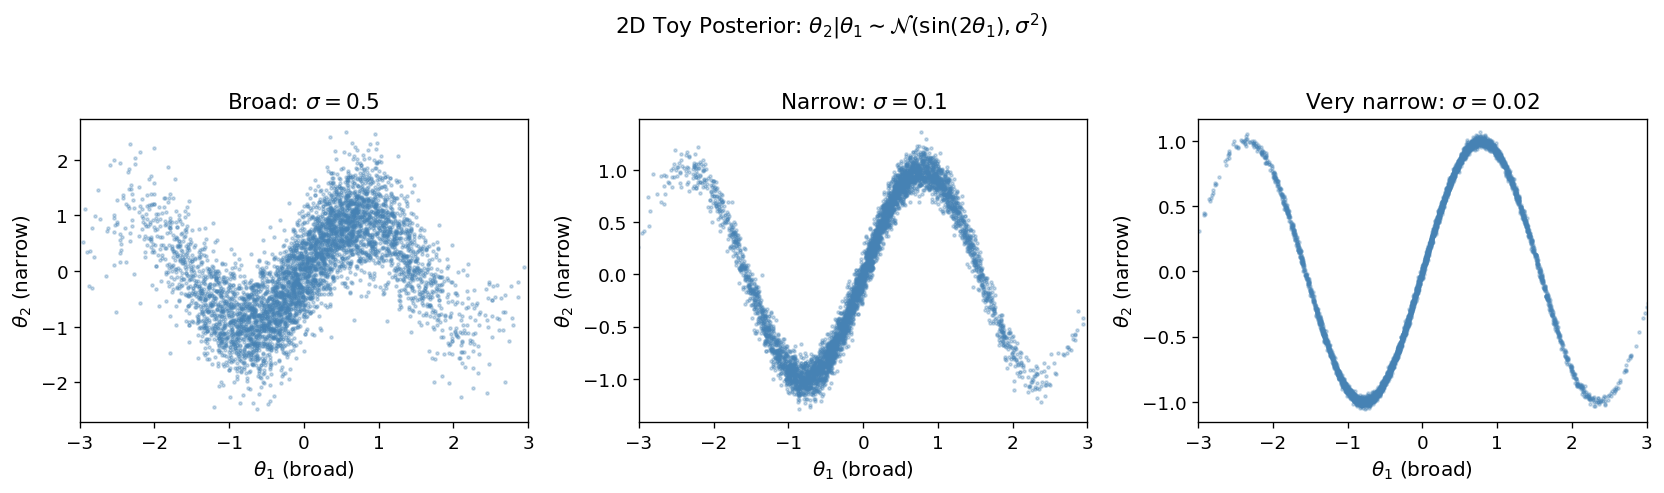

In [43]:
class ToyPosterior2D:
    """
    2D toy posterior:
      theta_1 ~ N(0, 1)            [broad dimension]
      theta_2 | theta_1 ~ N(sin(2*theta_1), sigma^2)  [narrow dimension, nonlinearly correlated]

    The nonlinear mean sin(2*theta_1) creates a curved, banana-shaped posterior
    that is challenging for simple proposals.
    We treat d as fixed (amortized over a single observation).
    """
    def __init__(self, sigma=0.1):
        self.sigma = sigma   # narrowness of theta_2 | theta_1
        self.dim = 2

    def log_prob(self, theta):
        """log p(theta_1, theta_2) — unnormalized joint."""
        theta1 = theta[:, 0]
        theta2 = theta[:, 1]
        log_p1 = -0.5 * theta1**2  # N(0,1)
        mu2 = torch.sin(2.0 * theta1)
        log_p2_given_1 = -0.5 * ((theta2 - mu2) / self.sigma)**2 - np.log(self.sigma)
        return log_p1 + log_p2_given_1

    def sample(self, n):
        """Draw exact samples (ground truth)."""
        theta1 = torch.randn(n)
        mu2 = torch.sin(2.0 * theta1)
        theta2 = mu2 + self.sigma * torch.randn(n)
        return torch.stack([theta1, theta2], dim=1)

    def conditional_mean(self, theta1):
        return torch.sin(2.0 * theta1)


class ToyPosterior3D:
    """
    3D toy posterior:
      theta_1 ~ N(0, 1)                           [broad]
      theta_2 ~ N(0.5 * theta_1, 0.8^2)           [moderately broad, correlated]
      theta_3 | theta_1, theta_2 ~ N(g(theta_1, theta_2), sigma^2)  [narrow]

    where g(theta_1, theta_2) = sin(theta_1) * cos(theta_2)  — nonlinear mean.

    This mimics the GW setting where phi_c (theta_3) is nearly deterministic
    given the other parameters but its mean varies nontrivially.
    """
    def __init__(self, sigma=0.05):
        self.sigma = sigma
        self.dim = 3

    def log_prob(self, theta):
        theta1 = theta[:, 0]
        theta2 = theta[:, 1]
        theta3 = theta[:, 2]
        log_p1 = -0.5 * theta1**2
        log_p2 = -0.5 * ((theta2 - 0.5 * theta1) / 0.8)**2 - np.log(0.8)
        mu3 = torch.sin(theta1) * torch.cos(theta2)
        log_p3 = -0.5 * ((theta3 - mu3) / self.sigma)**2 - np.log(self.sigma)
        return log_p1 + log_p2 + log_p3

    def sample(self, n):
        theta1 = torch.randn(n)
        theta2 = 0.5 * theta1 + 0.8 * torch.randn(n)
        mu3 = torch.sin(theta1) * torch.cos(theta2)
        theta3 = mu3 + self.sigma * torch.randn(n)
        return torch.stack([theta1, theta2, theta3], dim=1)

    def conditional_mean_narrow(self, theta1, theta2):
        return torch.sin(theta1) * torch.cos(theta2)


# Quick visualization of the 2D posterior shape
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sigmas = [0.5, 0.1, 0.02]
titles = [r'Broad: $\sigma=0.5$', r'Narrow: $\sigma=0.1$', r'Very narrow: $\sigma=0.02$']

for ax, sigma, title in zip(axes, sigmas, titles):
    post = ToyPosterior2D(sigma=sigma)
    samples = post.sample(5000)
    ax.scatter(samples[:, 0].numpy(), samples[:, 1].numpy(),
               alpha=0.3, s=3, c='steelblue')
    ax.set_xlabel(r'$\theta_1$ (broad)')
    ax.set_ylabel(r'$\theta_2$ (narrow)')
    ax.set_title(title)
    ax.set_xlim(-3, 3)

plt.suptitle('2D Toy Posterior: $\\theta_2 | \\theta_1 \\sim \\mathcal{N}(\\sin(2\\theta_1), \\sigma^2)$',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('posterior_shapes.png', bbox_inches='tight')
plt.show()

## 5. Training Utilities

We implement three training objectives:

1. **Forward KL / NLL** (standard NPE): $\mathcal{L} = -\mathbb{E}_{\theta \sim p}[\log q_\phi(\theta)]$  
2. **Reverse KL**: $\mathcal{L} = \mathbb{E}_{\theta \sim q_\phi}[\log q_\phi(\theta) - \log p(\theta)]$  
3. **Synthetic marginalization** (Dingo trick): train NPE only on broad dimensions, sample narrow dimension analytically

In [44]:
def train_forward_kl(flow, posterior, n_epochs=300, batch_size=512,
                     lr=1e-3, n_train=50000, verbose=True):
    """
    Train flow with forward KL (= NLL on samples from true posterior).
    This is the standard NPE objective used in Dingo.
    """
    flow = flow.to(device)
    optimizer = optim.Adam(flow.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)

    # Pre-sample training data from true posterior
    train_data = posterior.sample(n_train).to(device)

    losses = []
    pbar = tqdm(range(n_epochs), desc='Forward KL') if verbose else range(n_epochs)

    for epoch in pbar:
        idx = torch.randperm(n_train)[:batch_size]
        batch = train_data[idx]
        optimizer.zero_grad()
        # Forward KL: minimize -E_p[log q]
        loss = -flow.log_prob(batch).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        if verbose and epoch % 50 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    return flow, losses


def train_reverse_kl(flow, posterior, n_epochs=300, batch_size=512,
                     lr=1e-3, verbose=True):
    """
    Train flow with reverse KL: minimize E_q[log q - log p].
    This is mode-seeking: concentrates on high-probability regions,
    but may miss posterior mass.
    """
    flow = flow.to(device)
    optimizer = optim.Adam(flow.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)

    losses = []
    pbar = tqdm(range(n_epochs), desc='Reverse KL') if verbose else range(n_epochs)

    for epoch in pbar:
        optimizer.zero_grad()
        # Sample from current flow
        theta = flow.sample(batch_size)
        # Reverse KL: E_q[log q - log p]
        log_q = flow.log_prob(theta)
        log_p = posterior.log_prob(theta)
        loss = (log_q - log_p).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())
        if verbose and epoch % 50 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    return flow, losses


def train_alpha_divergence(flow, posterior, alpha=0.5,
                            n_epochs=400, batch_size=512,
                            lr=1e-3, verbose=True):
    """
    Train flow by minimizing the Renyi-alpha divergence bound.

    Key property: for 0 < alpha < 1, the gradient is a weighted
    combination of forward and reverse KL gradients, controlled by alpha.
    Mass-coverage is softened relative to forward KL but not lost entirely.
    """
    assert 0 < alpha < 1, "alpha must be in (0, 1)"
    flow = flow.to(device)
    optimizer = optim.Adam(flow.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)

    losses = []
    pbar = tqdm(range(n_epochs), desc=f'Alpha={alpha}') if verbose else range(n_epochs)

    for epoch in pbar:
        optimizer.zero_grad()

        # Sample from current flow (like reverse KL)
        theta = flow.sample(batch_size)

        # Compute log importance ratio log(p/q)
        log_q   = flow.log_prob(theta)
        log_p   = posterior.log_prob(theta)
        log_w   = log_p - log_q                    # log(p/q), shape [B]

        # Renyi-alpha objective:
        # L_alpha = -(1/alpha) * log( (1/B) * sum[ (p/q)^alpha ] )  =  -(1/alpha) * (logsumexp(alpha * log_w) - log(B))
        loss = -(1.0 / alpha) * (torch.logsumexp(alpha * log_w, dim=0) - np.log(batch_size))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

        if verbose and epoch % 50 == 0:
            pbar.set_postfix({'loss': f'{loss.item():.3f}'})

    return flow, losses

In [45]:
def iterative_is_refinement(posterior, n_iter=4, n_flow_samples=20000,
                             n_epochs_per_iter=200, batch_size=512,
                             dim=2, n_layers=8, hidden=128, verbose=True):
    """
    iterative IS refinement:
      iter 0: train flow on true posterior samples (standard forward KL)
      iter t: resample from IS-corrected distribution, retrain flow on resamples
    """
    epsilon_history = []

    # ── Iteration 0: standard forward KL on true samples ─────────────────────
    flow = ConditionalNormalizingFlow(dim=dim, context_dim=0,
                                      n_layers=n_layers, hidden=hidden)
    flow, _ = train_forward_kl(flow, posterior, n_epochs=n_epochs_per_iter,
                                verbose=verbose)
    theta, w, epsilon, logZ = importance_sampling(flow, posterior, n_flow_samples)
    epsilon_history.append(epsilon)
    if verbose:
        print(f"  Iter 0 (forward KL):  epsilon = {epsilon:.4f}")

    # ── Iterations 1..T: resample → retrain ───────────────────────────────────
    for t in range(1, n_iter):

        # Resample with replacement from IS-corrected distribution
        w_np = w.numpy()
        w_np = w_np / w_np.sum()   # renormalize to sum to 1
        idx  = np.random.choice(len(theta), size=n_flow_samples, replace=True, p=w_np)
        theta_resampled = theta[idx]   # [N, dim] — approximate samples from true posterior

        # Retrain flow on resampled points (forward KL on corrected samples)
        flow_new = ConditionalNormalizingFlow(dim=dim, context_dim=0,
                                              n_layers=n_layers, hidden=hidden)
        flow_new = flow_new.to(device)
        optimizer = optim.Adam(flow_new.parameters(), lr=1e-3)
        train_data = theta_resampled.to(device)

        for epoch in range(n_epochs_per_iter):
            idx_batch = torch.randperm(n_flow_samples)[:batch_size]
            loss = -flow_new.log_prob(train_data[idx_batch]).mean()
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        flow = flow_new
        theta, w, epsilon, logZ = importance_sampling(flow, posterior, n_flow_samples)
        epsilon_history.append(epsilon)
        if verbose:
            print(f"  Iter {t} (IS refinement): epsilon = {epsilon:.4f}")

    return flow, epsilon_history, epsilon, logZ


def train_annealed(posterior_class, sigma_target, sigma_start=1.0,
                   n_anneal_steps=8, n_epochs_per_step=100,
                   dim=2, n_layers=8, hidden=128,
                   batch_size=512, lr=1e-3, verbose=True):
    """
    annealed flow training: gradually narrow the posterior from
    sigma_start -> sigma_target over n_anneal_steps.
    """
    # geometric schedule: sigma_start -> sigma_target
    sigmas_schedule = np.geomspace(sigma_start, sigma_target, n_anneal_steps)
    print(f"  Annealing schedule: {[f'{s:.4f}' for s in sigmas_schedule]}") if verbose else None

    # initing the flow
    flow = ConditionalNormalizingFlow(dim=dim, context_dim=0,n_layers=n_layers, hidden=hidden)
    flow = flow.to(device)

    for step, sigma_t in enumerate(sigmas_schedule):
        # building posterior at current temperature
        posterior_t = posterior_class(sigma=sigma_t)

        # pre-sampling training data from it
        train_data = posterior_t.sample(50000).to(device)

        optimizer = optim.Adam(flow.parameters(), lr=lr)
        # cosine schedule per step
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs_per_step)

        for epoch in range(n_epochs_per_step):
            idx  = torch.randperm(50000)[:batch_size]
            loss = -flow.log_prob(train_data[idx]).mean()
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(flow.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        if verbose:
            print(f"    step {step+1}/{n_anneal_steps}  sigma_t={sigma_t:.4f}  done")

    return flow

## 6. Importance Sampling Utilities

Given a trained flow $q_\phi$, we:
1. Draw $n$ samples $\theta_i \sim q_\phi$
2. Compute weights $w_i = p(\theta_i) / q_\phi(\theta_i)$ (unnormalized posterior / proposal)
3. Compute $\epsilon = n_{\text{eff}} / n$ where $n_{\text{eff}} = (\sum w_i)^2 / \sum w_i^2$

In [7]:
# ── Faithful Synthetic Marginalization (Dingo-style grid trick) ───────────────
#   we treat p(theta2 | theta1) as a BLACK BOX
#           - evaluate log p(theta1, theta2) on a fine grid over theta2
#           - fit a Gaussian to the grid evaluations (like Dingo's phase grid)
#           - sample theta2 from the fitted Gaussian
#           - no knowledge of sigma or sin(2*theta1) used anywhere
#
# This is the faithful analog of Dingo's phi_c trick:
#   - Cache waveform modes once per theta1 sample  (here: evaluate posterior on grid)
#   - Evaluate likelihood across phi_c grid        (here: evaluate over theta2 grid)
#   - Sample phi_c from interpolated distribution  (here: fit Gaussian + sample)

@torch.no_grad()
def importance_sampling_faithful_synthetic(
        flow_broad,         # 1D flow trained on theta1 marginal only
        posterior,          # true posterior object (black box: only .log_prob used)
        n_samples=10000,
        grid_size=501,      # number of grid points over theta2 (dingo-us used 5001 :))
        theta2_range=(-3.0, 3.0),  # grid bounds for theta2
        device=device):
    """
    this mirrors what Dingo does for phi_c:
      1. Sample broad params from flow
      2. For each sample, sweep narrow param over a grid
      3. Fit/interpolate the conditional from the grid
      4. Sample narrow param from fitted conditional
      5. Run IS in the full joint space
    """
    flow_broad.eval()

    # ── Step 1: Sample broad dimension theta1 from the 1D flow ────────────────
    theta1 = flow_broad.sample(n_samples)[:, 0].cpu()   # shape [n_samples]

    # ── Step 2: For each theta1, evaluate log p(theta1, theta2) on a theta2 grid
    #    This is the "grid sweep" — analog of Dingo evaluating likelihood over phi_c
    #    Cost: n_samples * grid_size posterior evaluations
    #    (In Dingo this is cheap because waveform modes are cached — here log_prob is cheap)
    # ─────────────────────────────────────────────────────────────────────────
    theta2_grid = torch.linspace(theta2_range[0], theta2_range[1], grid_size)  # [G]

    # Expand to [n_samples, grid_size] for batch evaluation
    theta1_expanded = theta1.unsqueeze(1).expand(-1, grid_size)   # [N, G]
    theta2_expanded = theta2_grid.unsqueeze(0).expand(n_samples, -1)  # [N, G]

    # Flatten, evaluate, reshape — we call log_prob once for efficiency
    theta_grid_flat = torch.stack([theta1_expanded.reshape(-1), theta2_expanded.reshape(-1)], dim=1)   # [N*G, 2]

    # Evaluate in batches to avoid OOM on large grids
    batch_size_eval = 50000
    log_p_grid_flat = []
    for start in range(0, theta_grid_flat.shape[0], batch_size_eval):
        chunk = theta_grid_flat[start:start+batch_size_eval]
        log_p_grid_flat.append(posterior.log_prob(chunk))
    log_p_grid_flat = torch.cat(log_p_grid_flat)   # [N*G]

    log_p_grid = log_p_grid_flat.reshape(n_samples, grid_size)   # [N, G]

    # ── Step 3: Extract conditional log p(theta2 | theta1) from the grid
    #    For fixed theta1, the grid gives log p(theta1, theta2) up to a constant.
    #    The conditional is: log p(theta2|theta1) = log p(theta1,theta2) - log p(theta1)
    #    Since log p(theta1) is constant w.r.t. theta2, we can normalize across the grid.
    # ─────────────────────────────────────────────────────────────────────────

    # Normalize to get log conditional probabilities (subtract logsumexp for stability)
    log_normalizer = torch.logsumexp(log_p_grid, dim=1, keepdim=True)   # [N, 1]
    log_cond = log_p_grid - log_normalizer   # [N, G], normalized over grid
    cond_probs = torch.exp(log_cond)          # [N, G], sums to ~1 over grid points

    # ── Step 4: Fit a Gaussian to the conditional by computing grid moments
    #    mean  = sum_g theta2_g * p(theta2_g | theta1)
    #    var   = sum_g (theta2_g - mean)^2 * p(theta2_g | theta1)
    # ─────────────────────────────────────────────────────────────────────────
    theta2_grid_exp = theta2_grid.unsqueeze(0)   # [1, G]

    mu_est    = (cond_probs * theta2_grid_exp).sum(dim=1)              # [N]
    var_est   = (cond_probs * (theta2_grid_exp - mu_est.unsqueeze(1))**2).sum(dim=1)  # [N]
    sigma_est = torch.sqrt(var_est.clamp(min=1e-8))                    # [N], clamp for safety

    # ── Step 5: Sample theta2 from the fitted Gaussian N(mu_est, sigma_est^2)
    # ─────────────────────────────────────────────────────────────────────────
    theta2_synth = mu_est + sigma_est * torch.randn(n_samples)   # [N]

    # ── Step 6: Compute IS weights in the full joint space
    #    Proposal: q(theta1, theta2) = q_flow(theta1) * q_fitted(theta2 | theta1)
    #    where q_fitted(theta2 | theta1) = N(mu_est, sigma_est^2)  [per-sample Gaussian]
    # ─────────────────────────────────────────────────────────────────────────
    theta_full = torch.stack([theta1, theta2_synth], dim=1)   # [N, 2]

    # log q_flow(theta1)
    log_q_broad = flow_broad.log_prob(theta1.unsqueeze(1).to(device)).cpu()   # [N]

    # log q_fitted(theta2 | theta1) = log N(theta2; mu_est, sigma_est^2)
    log_q_narrow_fitted = (
        -0.5 * ((theta2_synth - mu_est) / sigma_est)**2
        - torch.log(sigma_est)
        - 0.5 * np.log(2 * np.pi)
    )   # [N]

    log_q_total = log_q_broad + log_q_narrow_fitted   # [N]

    # log p(theta1, theta2) — true unnormalized posterior
    log_p_total = posterior.log_prob(theta_full)   # [N]

    # IS weights
    log_w = log_p_total - log_q_total
    log_w_normalized = log_w - torch.logsumexp(log_w, dim=0)
    w_normalized = torch.exp(log_w_normalized)

    n_eff   = 1.0 / (w_normalized**2).sum().item()
    epsilon = n_eff / n_samples
    log_Z   = torch.logsumexp(log_w, dim=0) - np.log(n_samples)

    return theta_full, w_normalized, epsilon, log_Z.item(), mu_est, sigma_est

#### **Note on Bayesian evidence estimation via IS**

The evidence $p(d) = \int p(d|\theta)p(\theta)\,d\theta$ can be rewritten as an expectation under the proposal $q$:

$$p(d) = \mathbb{E}_{q}\left[\frac{p(d|\theta)p(\theta)}{q(\theta)}\right] = \mathbb{E}_q[w]$$

The Monte Carlo estimate with $n$ samples $\theta_i \sim q$ is then:

$$\hat{p}(d) = \frac{1}{n}\sum_i w_i$$

Taking the log and using the logsumexp trick for numerical stability:

$$\log \hat{p}(d) = \log\sum_i w_i - \log n = \texttt{logsumexp}(\log w_i) - \log n$$

Let's note that `posterior.log_prob` returns the **unnormalized** log joint (missing $-\frac{1}{2}\log 2\pi$ constants), so log Z values have an additive constant that is identical across all methods. <br>

In [8]:
@torch.no_grad()
def importance_sampling(flow, posterior, n_samples=10000):
    """
    Run IS: draw from flow, reweight by true posterior / flow density.
    Returns: samples, normalized weights, log efficiency.
    """
    flow.eval()
    theta = flow.sample(n_samples)           # theta_i ~ q
    log_q = flow.log_prob(theta)             # log q(theta_i)
    log_p = posterior.log_prob(theta)        # log p(theta_i)  [unnormalized]

    log_w = log_p - log_q                    # log importance weights

    # numerically stable normalization
    log_w_normalized = log_w - torch.logsumexp(log_w, dim=0)
    w_normalized = torch.exp(log_w_normalized)

    # sample eff
    n_eff = 1.0 / (w_normalized**2).sum().item()
    epsilon = n_eff / n_samples

    # log evidence estimate (+ constant, from prior normalization. See above)
    log_Z = torch.logsumexp(log_w, dim=0) - np.log(n_samples)

    return theta.cpu(), w_normalized.cpu(), epsilon, log_Z.item()


@torch.no_grad()
def importance_sampling_with_synthetic_narrow(
        flow_broad, posterior, narrow_sigma, n_samples=10000,
        narrow_grid_size=501, dim=2):
    """
    The 'Dingo trick' for 2D case:
    - Flow only models the broad dimension theta_1
    - Narrow dimension theta_2 is sampled analytically from the
      conditional posterior p(theta_2 | theta_1) evaluated on a grid

    This avoids asking the flow to represent the narrow conditional.
    """
    flow_broad.eval()

    # 1. Sample broad dimension from 1D flow
    theta1 = flow_broad.sample(n_samples)[:, 0]   # shape [n]

    # 2. For each theta1, analytically sample theta2 from p(theta2|theta1)
    # The conditional mean is sin(2*theta1) and std is narrow_sigma
    mu2 = torch.sin(2.0 * theta1)   # conditional mean
    # Sample from the exact conditional (we know it's Gaussian here)
    theta2 = mu2 + narrow_sigma * torch.randn_like(theta1)

    theta = torch.stack([theta1, theta2], dim=1).to(device)

    # 3. Proposal density: q(theta1, theta2) = q_broad(theta1) * p(theta2|theta1)
    #    (since we sample theta2 exactly from the conditional, this cancels in IS)
    log_q_broad = flow_broad.log_prob(theta1.unsqueeze(1).to(device))
    log_q_narrow = -0.5 * ((theta2 - mu2.to(device)) / narrow_sigma)**2 - np.log(narrow_sigma)
    log_q = log_q_broad + log_q_narrow

    log_p = posterior.log_prob(theta.cpu()).to(device)
    log_w = log_p - log_q

    log_w_normalized = log_w - torch.logsumexp(log_w, dim=0)
    w_normalized = torch.exp(log_w_normalized)
    n_eff = 1.0 / (w_normalized**2).sum().item()
    epsilon = n_eff / n_samples
    log_Z = torch.logsumexp(log_w, dim=0) - np.log(n_samples)

    return theta.cpu(), w_normalized.cpu(), epsilon, log_Z.item()


print("IS utilities defined.")

IS utilities defined.


## 7. Experiment 1: 2D Posterior — Effect of Narrowness on IS Efficiency

We sweep $\sigma$ from $0.5$ (broad) to $0.01$ (very narrow) and measure:
- IS efficiency $\epsilon$ for forward KL trained flow
- IS efficiency $\epsilon$ for reverse KL trained flow  
- IS efficiency $\epsilon$ for synthetic marginalization

**Hypothesis**: Forward KL efficiency degrades with $\sigma$, reverse KL efficiency may be artificially high (mode-seeking) but IS is biased, synthetic marginalization stays high.

In [25]:

# ── 2D Experiment: sweep sigma, compare fKL / rKL / alpha=0.5 / iterative refinement / annealed training / Synthetic ──

sigmas   = [0.3, 0.1, 0.04, 0.02, 0.01] #0.3, 0.15,
N_EPOCHS = 400
N_IS     = 20000

results_fkl    = []
results_rkl    = []
results_a05    = []   # alpha = 0.5
# results_a08    = []   # alpha = 0.8
results_anneal = []
# results_iter   = []   # iterative refinement
results_synth  = []

print(f"Running 2D experiments across {len(sigmas)} sigma values...")
print(f"Device: {device}\n")

for sigma in sigmas:
    print(f"=== sigma = {sigma} ===")
    posterior = ToyPosterior2D(sigma=sigma)

    # --- Forward KL ---
    flow_fkl = ConditionalNormalizingFlow(dim=2, context_dim=0, n_layers=8, hidden=128)
    flow_fkl, _ = train_forward_kl(flow_fkl, posterior, n_epochs=N_EPOCHS, verbose=False)
    theta_fkl, w_fkl, eps_fkl, logZ_fkl = importance_sampling(flow_fkl, posterior, N_IS)
    results_fkl.append({'sigma': sigma, 'epsilon': eps_fkl, 'logZ': logZ_fkl, 'theta': theta_fkl, 'weights': w_fkl})
    print(f"  Forward KL  (alpha=1):   epsilon = {eps_fkl:.4f}")

    # --- Reverse KL ---
    flow_rkl = ConditionalNormalizingFlow(dim=2, context_dim=0, n_layers=8, hidden=128)
    flow_rkl, _ = train_reverse_kl(flow_rkl, posterior, n_epochs=N_EPOCHS, verbose=False)
    theta_rkl, w_rkl, eps_rkl, logZ_rkl = importance_sampling(flow_rkl, posterior, N_IS)
    results_rkl.append({'sigma': sigma, 'epsilon': eps_rkl, 'logZ': logZ_rkl, 'theta': theta_rkl, 'weights': w_rkl})
    print(f"  Reverse KL  (alpha→0):   epsilon = {eps_rkl:.4f}")

    # --- Alpha = 0.5 ---
    flow_a05 = ConditionalNormalizingFlow(dim=2, context_dim=0, n_layers=8, hidden=128)
    flow_a05, _ = train_alpha_divergence(flow_a05, posterior, alpha=0.5,
                                          n_epochs=N_EPOCHS, verbose=False)
    theta_a05, w_a05, eps_a05, logZ_a05 = importance_sampling(flow_a05, posterior, N_IS)
    results_a05.append({'sigma': sigma, 'epsilon': eps_a05, 'logZ': logZ_a05, 'theta': theta_a05, 'weights': w_a05})
    print(f"  Alpha=0.5:               epsilon = {eps_a05:.4f}")

    # --- Annealed training ---
    flow_anneal = train_annealed(ToyPosterior2D, sigma_target=sigma, sigma_start=1.0, n_anneal_steps=10, n_epochs_per_step=400, dim=2, verbose=False
    )
    theta_anneal, w_anneal, eps_anneal, logZ_anneal = importance_sampling(flow_anneal, posterior, N_IS)
    results_anneal.append({'sigma': sigma, 'epsilon': eps_anneal, 'logZ': logZ_anneal, 'theta': theta_anneal, 'weights': w_anneal})
    print(f"  Annealed training:       epsilon = {eps_anneal:.4f}")


    # # --- Iterative IS refinement ---
    # _, eps_history, eps_iter, logZ_iter = iterative_is_refinement(posterior, n_iter=8, n_flow_samples=N_IS, n_epochs_per_iter=300, dim=2, verbose=False)
    # results_iter.append({'sigma': sigma, 'epsilon': eps_iter,
    #                     'logZ': logZ_iter, 'history': eps_history})
    # print(f"  Iterative refinement:    epsilon = {eps_iter:.4f}  "
    #       f"(history: {[f'{e:.3f}' for e in eps_history]})")


    # --- Faithful synthetic (Dingo trick) ---
    flow_1d = ConditionalNormalizingFlow(dim=1, context_dim=0, n_layers=6, hidden=64)
    train_1d = posterior.sample(50000)[:, :1].to(device)
    opt_1d   = optim.Adam(flow_1d.parameters(), lr=1e-3)
    flow_1d  = flow_1d.to(device)
    for _ in range(N_EPOCHS):
        idx  = torch.randperm(50000)[:512]
        loss = -flow_1d.log_prob(train_1d[idx]).mean()
        opt_1d.zero_grad(); loss.backward(); opt_1d.step()

    theta_synth, w_synth, eps_synth, logZ_synth, _, sigma_est = importance_sampling_faithful_synthetic(flow_1d, posterior, n_samples=N_IS, grid_size=501, theta2_range=(-3.0, 3.0))
    results_synth.append({'sigma': sigma, 'epsilon': eps_synth, 'logZ': logZ_synth, 'theta': theta_synth, 'weights': w_synth})
    print(f"  Faithful synthetic:      epsilon = {eps_synth:.4f}")
    print(f"    (grid sigma_est ~ {sigma_est.mean().item():.4f}, true: {sigma})")

Running 2D experiments across 5 sigma values...
Device: cuda

=== sigma = 0.3 ===
  Forward KL  (alpha=1):   epsilon = 0.9764
  Reverse KL  (alpha→0):   epsilon = 0.9897
  Alpha=0.5:               epsilon = 0.9677
  Annealed training:       epsilon = 0.9967
  Faithful synthetic:      epsilon = 0.9987
    (grid sigma_est ~ 0.3000, true: 0.3)

=== sigma = 0.1 ===
  Forward KL  (alpha=1):   epsilon = 0.9200
  Reverse KL  (alpha→0):   epsilon = 0.9889
  Alpha=0.5:               epsilon = 0.6649
  Annealed training:       epsilon = 0.9924
  Faithful synthetic:      epsilon = 0.9999
    (grid sigma_est ~ 0.1000, true: 0.1)

=== sigma = 0.04 ===
  Forward KL  (alpha=1):   epsilon = 0.1176
  Reverse KL  (alpha→0):   epsilon = 0.6918
  Alpha=0.5:               epsilon = 0.0022
  Annealed training:       epsilon = 0.9800
  Faithful synthetic:      epsilon = 0.9984
    (grid sigma_est ~ 0.0400, true: 0.04)

=== sigma = 0.02 ===
  Forward KL  (alpha=1):   epsilon = 0.5352
  Reverse KL  (alpha→0): 

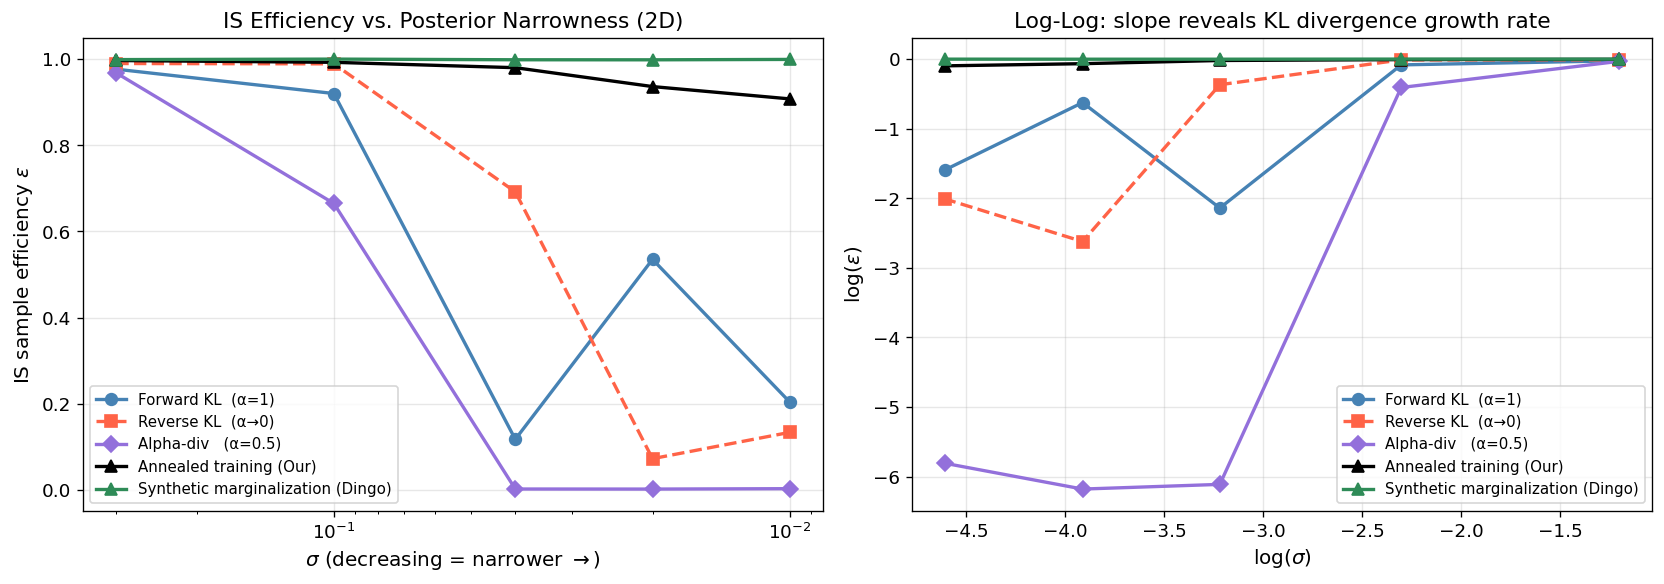

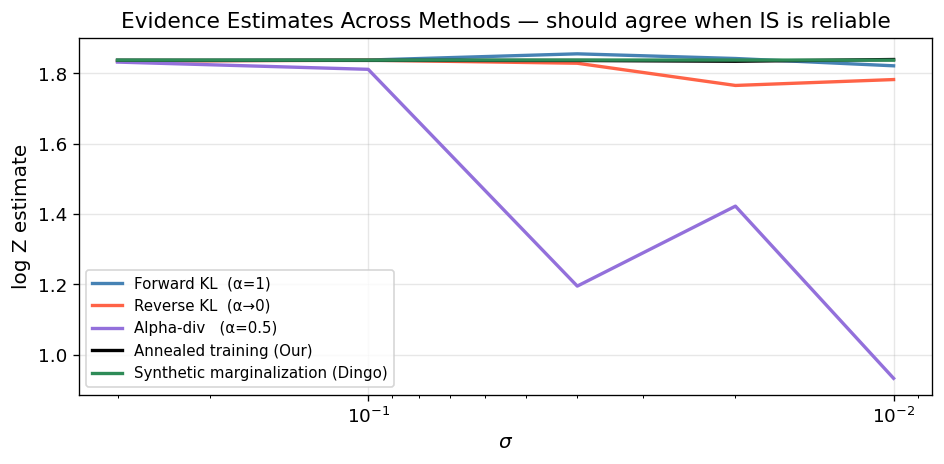

In [26]:
# ── Plot: 2D efficiency + log-log ─────────────────────────────────────────────

eps_fkl_vals   = [r['epsilon'] for r in results_fkl]
eps_rkl_vals   = [r['epsilon'] for r in results_rkl]
eps_a05_vals   = [r['epsilon'] for r in results_a05]
# eps_a08_vals   = [r['epsilon'] for r in results_a08]
eps_anneal_vals = [r['epsilon'] for r in results_anneal]

eps_synth_vals = [r['epsilon'] for r in results_synth]

methods = [
    (eps_fkl_vals,   'o-',  'steelblue',   'Forward KL  (α=1)'),
    (eps_rkl_vals,   's--', 'tomato',       'Reverse KL  (α→0)'),
    (eps_a05_vals,   'D-',  'mediumpurple', 'Alpha-div   (α=0.5)'),
    #(eps_a08_vals,   'P-',  'darkorange',   'Alpha-div   (α=0.8)'),
    (eps_anneal_vals, 'k^-', 'black',        'Annealed training (Our)'),
    (eps_synth_vals, '^-',  'seagreen',     'Synthetic marginalization (Dingo)'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw efficiency
ax = axes[0]
for vals, marker, color, label in methods:
    ax.plot(sigmas, vals, marker, color=color, lw=2, ms=7, label=label)
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'$\sigma$ (decreasing = narrower $\rightarrow$)')
ax.set_ylabel(r'IS sample efficiency $\epsilon$')
ax.set_title('IS Efficiency vs. Posterior Narrowness (2D)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: log-log
ax2 = axes[1]
log_sig = np.log(sigmas)
for vals, marker, color, label in methods:
    log_eps = np.log(np.clip(vals, 1e-6, 1))
    ax2.plot(log_sig, log_eps, marker, color=color, lw=2, ms=7, label=label)
ax2.set_xlabel(r'$\log(\sigma)$')
ax2.set_ylabel(r'$\log(\epsilon)$')
ax2.set_title(r'Log-Log: slope reveals KL divergence growth rate')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('efficiency_vs_sigma_alpha.pdf', bbox_inches='tight')
plt.show()

# ── evidence quality across methods ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for res_list, _, color, label in zip(
    [results_fkl, results_rkl, results_a05, results_anneal, results_synth], # ,results_a08
    *zip(*[(m[1], m[2], m[3]) for m in methods])
):
    logZs = [r['logZ'] for r in res_list]
    ax.plot(sigmas, logZs, color=color, lw=2, label=label)

ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel('log Z estimate')
ax.set_title('Evidence Estimates Across Methods — should agree when IS is reliable')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('logZ_comparison.pdf', bbox_inches='tight')
plt.show()

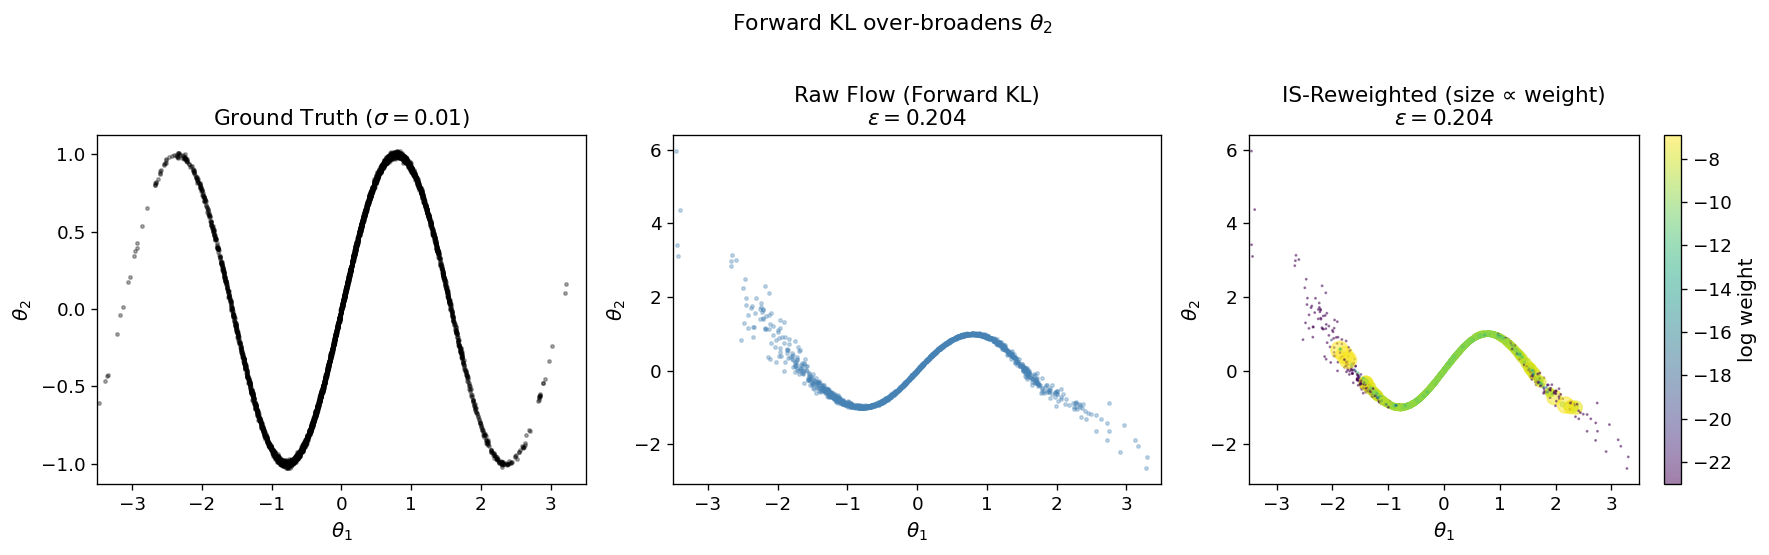

With sigma=0.01, forward KL gives epsilon=0.2040


In [33]:
# ── Qualitative: show IS-corrected vs raw flow samples for sigma=0.02 ────────
sigma_show = 0.01 #0.02
idx_show = sigmas.index(sigma_show)
posterior_show = ToyPosterior2D(sigma=sigma_show)

res_fkl   = results_fkl[idx_show]
true_samples = posterior_show.sample(5000).numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Ground truth
axes[0].scatter(true_samples[:, 0], true_samples[:, 1],
                alpha=0.3, s=4, c='black')
axes[0].set_title(f'Ground Truth ($\\sigma={sigma_show}$)')
axes[0].set_xlabel(r'$\theta_1$'); axes[0].set_ylabel(r'$\theta_2$')

# Raw flow samples (forward KL)
raw_samples = res_fkl['theta'].numpy()
axes[1].scatter(raw_samples[:2000, 0], raw_samples[:2000, 1],
                alpha=0.3, s=4, c='steelblue')
eps_val = res_fkl['epsilon']
axes[1].set_title(f'Raw Flow (Forward KL)\n$\\epsilon={eps_val:.3f}$')
axes[1].set_xlabel(r'$\theta_1$'); axes[1].set_ylabel(r'$\theta_2$')

# IS-reweighted samples (scatter with size proportional to weight)
w = res_fkl['weights'].numpy()
w_plot = w / w.max() * 20  # rescale for visibility
scatter = axes[2].scatter(raw_samples[:2000, 0], raw_samples[:2000, 1],
                          s=w_plot[:2000] * 50 + 0.5,
                          alpha=0.5, c=np.log(w[:2000] + 1e-10),
                          cmap='viridis')
plt.colorbar(scatter, ax=axes[2], label='log weight')
axes[2].set_title(f'IS-Reweighted (size ∝ weight)\n$\\epsilon={eps_val:.3f}$')
axes[2].set_xlabel(r'$\theta_1$'); axes[2].set_ylabel(r'$\theta_2$')

for ax in axes:
    ax.set_xlim(-3.5, 3.5)

plt.suptitle('Forward KL over-broadens $\\theta_2$', y=1.02)
plt.tight_layout()
plt.savefig('qualitative_2d.png', bbox_inches='tight')
plt.show()

print(f"With sigma={sigma_show}, forward KL gives epsilon={eps_val:.4f}")

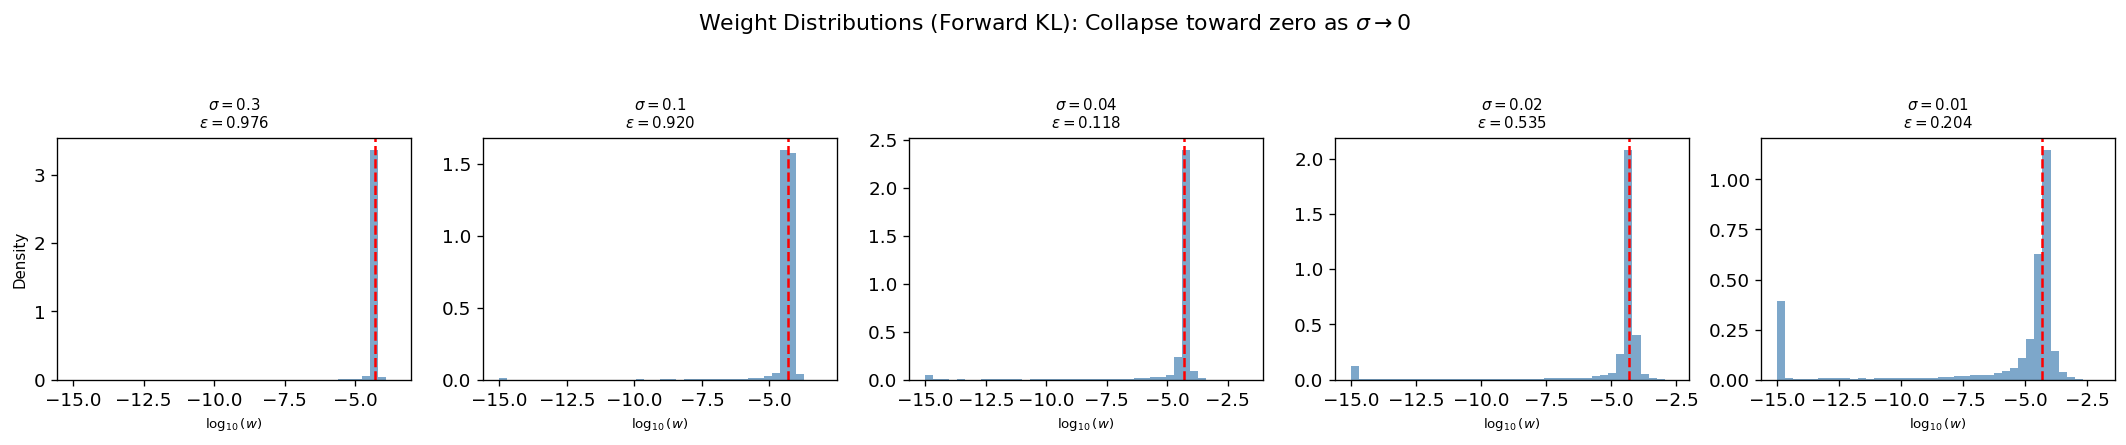

In [34]:
# ── Weight distribution analysis ──────────────────────────────────────────────
fig, axes = plt.subplots(1, len(sigmas), figsize=(18, 3.5))

for i, (sigma, res) in enumerate(zip(sigmas, results_fkl)):
    w = res['weights'].numpy()
    axes[i].hist(np.log10(w + 1e-15), bins=40, color='steelblue', alpha=0.7, density=True)
    axes[i].axvline(np.log10(1/len(w)), color='red', ls='--', lw=1.5, label='uniform')
    axes[i].set_title(f'$\\sigma={sigma}$\n$\\epsilon={res["epsilon"]:.3f}$', fontsize=9)
    axes[i].set_xlabel('$\\log_{10}(w)$', fontsize=8)
    if i == 0:
        axes[i].set_ylabel('Density', fontsize=9)

plt.suptitle('Weight Distributions (Forward KL): Collapse toward zero as $\\sigma \\to 0$',
             y=1.05)
plt.tight_layout()
plt.savefig('weight_distributions.png', bbox_inches='tight')
plt.show()

## 8. Experiment 2: 3D Posterior — Mimicking GW Inference

Now we add a second broad dimension ($\theta_2$) correlated with $\theta_1$, and a third extremely narrow dimension ($\theta_3$, mimicking $\phi_c$). This is the closest analog to the actual Dingo-IS setting.

We compare:
- **Baseline**: Full 3D flow with forward KL
- **Dingo trick**: 2D flow for $(\theta_1, \theta_2)$ + analytic $\theta_3$
- **Oracle**: 2D flow for $(\theta_1, \theta_2)$ + exact Gaussian samples for $\theta_3$

In [35]:
# ── 3D Experiment: Full flow vs Faithful Synthetic Marginalization ─────────────

def run_3d_synthetic_faithful(flow_2d, posterior3d, n_samples,
                               grid_size=501, theta3_range=(-3.0, 3.0)):
    flow_2d.eval()

    # Step 1: sample broad dims from 2D flow
    theta12 = flow_2d.sample(n_samples).cpu()
    theta1, theta2 = theta12[:, 0], theta12[:, 1]

    # Step 2: evaluate log p(theta1, theta2, theta3) on a theta3 grid
    theta3_grid = torch.linspace(theta3_range[0], theta3_range[1], grid_size)
    theta_grid_flat = torch.stack([
        theta1.unsqueeze(1).expand(-1, grid_size).reshape(-1),
        theta2.unsqueeze(1).expand(-1, grid_size).reshape(-1),
        theta3_grid.unsqueeze(0).expand(n_samples, -1).reshape(-1),
    ], dim=1)  # [N*G, 3]

    # Batched evaluation to avoid OOM
    log_p_chunks = [
        posterior3d.log_prob(theta_grid_flat[s:s+50000])
        for s in range(0, theta_grid_flat.shape[0], 50000)
    ]
    log_p_grid = torch.cat(log_p_chunks).reshape(n_samples, grid_size)  # [N, G]

    # Step 3: normalize across grid → empirical conditional
    cond_probs = torch.exp(log_p_grid - torch.logsumexp(log_p_grid, dim=1, keepdim=True))

    # Step 4: estimate conditional mean and std from grid moments
    theta3_grid_exp = theta3_grid.unsqueeze(0)                                        # [1, G]
    mu3_est    = (cond_probs * theta3_grid_exp).sum(dim=1)                            # [N]
    sigma3_est = torch.sqrt( (cond_probs * (theta3_grid_exp - mu3_est.unsqueeze(1))**2).sum(dim=1).clamp(min=1e-8)) # [N]

    # Step 5: sample theta3 from fitted Gaussian
    theta3_synth = mu3_est + sigma3_est * torch.randn(n_samples)
    theta_full   = torch.stack([theta1, theta2, theta3_synth], dim=1)

    # Step 6: compute IS weights
    log_q_2d     = flow_2d.log_prob(theta12.to(device)).cpu()
    log_q_narrow = (
        - 0.5 * ((theta3_synth - mu3_est) / sigma3_est)**2
        - torch.log(sigma3_est)
        - 0.5 * np.log(2 * np.pi)
    )
    log_w = posterior3d.log_prob(theta_full) - (log_q_2d + log_q_narrow)

    log_w_norm   = log_w - torch.logsumexp(log_w, dim=0)
    w_norm       = torch.exp(log_w_norm)
    epsilon      = (1.0 / (w_norm**2).sum().item()) / n_samples
    log_Z        = torch.logsumexp(log_w, dim=0) - np.log(n_samples)

    return theta_full, w_norm, epsilon, log_Z.item(), mu3_est, sigma3_est


# ── 3D Experiment: Full flow vs Alpha=0.5 vs Annealed vs Faithful synthetic ───
sigmas_3d        = [0.3, 0.1, 0.05, 0.02, 0.01]
results_3d_full  = []
results_3d_a05   = []
results_3d_anneal = []
results_3d_synth = []

print("Running 3D experiments...\n")

for sigma in sigmas_3d:
    print(f"=== sigma = {sigma} ===")
    posterior3d = ToyPosterior3D(sigma=sigma)

    # --- Baseline: full 3D flow, forward KL ---
    flow_3d = ConditionalNormalizingFlow(dim=3, context_dim=0, n_layers=10, hidden=128)
    flow_3d, _ = train_forward_kl(flow_3d, posterior3d, n_epochs=500,
                                   batch_size=512, verbose=False)
    _, _, eps_3d, logZ_3d = importance_sampling(flow_3d, posterior3d, N_IS)
    results_3d_full.append({'sigma': sigma, 'epsilon': eps_3d, 'logZ': logZ_3d})
    print(f"  Full 3D fKL:               epsilon = {eps_3d:.4f}")

    # --- Alpha = 0.5 ---
    flow_a05 = ConditionalNormalizingFlow(dim=3, context_dim=0, n_layers=10, hidden=128)
    flow_a05, _ = train_alpha_divergence(flow_a05, posterior3d, alpha=0.5,
                                          n_epochs=500, batch_size=512, verbose=False)
    _, _, eps_a05, logZ_a05 = importance_sampling(flow_a05, posterior3d, N_IS)
    results_3d_a05.append({'sigma': sigma, 'epsilon': eps_a05, 'logZ': logZ_a05})
    print(f"  Alpha=0.5:                 epsilon = {eps_a05:.4f}")

    # --- Annealed training ---
    flow_anneal = train_annealed(
        ToyPosterior3D, sigma_target=sigma, sigma_start=1.0, n_anneal_steps=8, n_epochs_per_step=400, dim=3, n_layers=10, hidden=128, verbose=False)
    _, _, eps_anneal, logZ_anneal = importance_sampling(flow_anneal, posterior3d, N_IS)
    results_3d_anneal.append({'sigma': sigma, 'epsilon': eps_anneal, 'logZ': logZ_anneal})
    print(f"  Annealed:                  epsilon = {eps_anneal:.4f}")

    # --- Faithful synthetic (Dingo trick) ---
    flow_2d = ConditionalNormalizingFlow(dim=2, context_dim=0, n_layers=8, hidden=128)
    flow_2d, _ = train_forward_kl(flow_2d,
                                  type('P2D', (), {'sample'  : lambda self, n: posterior3d.sample(n)[:, :2], 'log_prob': lambda self, x: x.new_zeros(x.shape[0])})(),
                                  n_epochs=400, verbose=False)
    with torch.no_grad():
        _, _, eps_synth, logZ_synth, _, sigma3_est = run_3d_synthetic_faithful(
            flow_2d, posterior3d, n_samples=N_IS
        )
    results_3d_synth.append({'sigma': sigma, 'epsilon': eps_synth, 'logZ': logZ_synth})
    print(f"  Faithful synthetic (Dingo): epsilon = {eps_synth:.4f}")
    print(f"    (grid sigma3_est ~ {sigma3_est.mean().item():.4f}, true: {sigma})")

    # --- Iterative IS refinement (disabled temporarily) ---
    # _, eps_history, eps_iter, logZ_iter = iterative_is_refinement(
    #     posterior3d, n_iter=4, n_flow_samples=N_IS,
    #     n_epochs_per_iter=200, dim=3, n_layers=10, verbose=False
    # )
    # results_3d_iter.append({'sigma': sigma, 'epsilon': eps_iter,
    #                         'logZ': logZ_iter, 'history': eps_history})
    # print(f"  Iterative refinement:      epsilon = {eps_iter:.4f}")

    print()

print("Done.")

Running 3D experiments...

=== sigma = 0.3 ===
  Full 3D fKL:               epsilon = 0.9899
  Alpha=0.5:                 epsilon = 0.9696
  Annealed:                  epsilon = 0.9950
  Faithful synthetic (Dingo): epsilon = 0.9996
    (grid sigma3_est ~ 0.3000, true: 0.3)

=== sigma = 0.1 ===
  Full 3D fKL:               epsilon = 0.9691
  Alpha=0.5:                 epsilon = 0.8869
  Annealed:                  epsilon = 0.9903
  Faithful synthetic (Dingo): epsilon = 0.9993
    (grid sigma3_est ~ 0.1000, true: 0.1)

=== sigma = 0.05 ===
  Full 3D fKL:               epsilon = 0.9313
  Alpha=0.5:                 epsilon = 0.2394
  Annealed:                  epsilon = 0.9788
  Faithful synthetic (Dingo): epsilon = 0.9984
    (grid sigma3_est ~ 0.0500, true: 0.05)

=== sigma = 0.02 ===
  Full 3D fKL:               epsilon = 0.8099
  Alpha=0.5:                 epsilon = 0.0007
  Annealed:                  epsilon = 0.9123
  Faithful synthetic (Dingo): epsilon = 0.9993
    (grid sigma3_est 

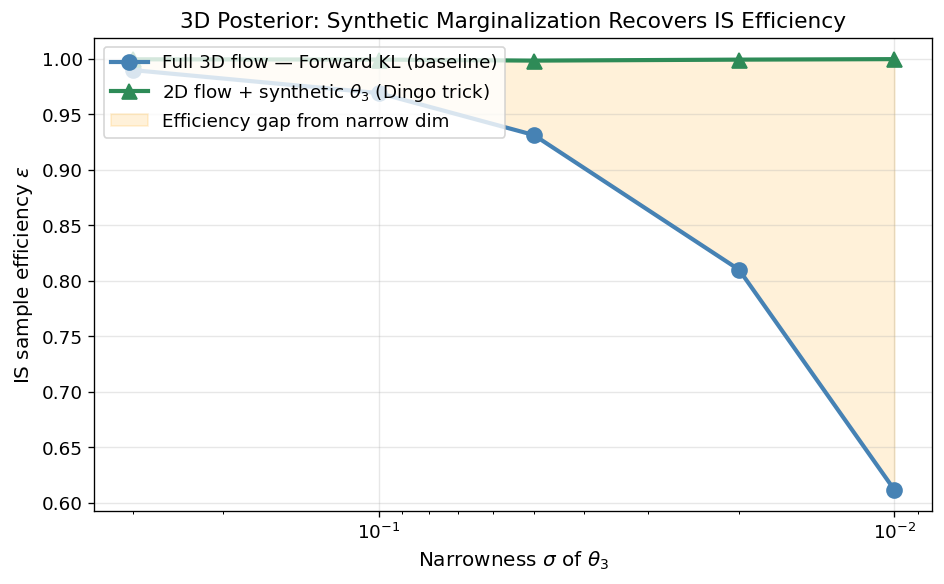

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))

eps_full  = [r['epsilon'] for r in results_3d_full]
eps_synth = [r['epsilon'] for r in results_3d_synth]

ax.plot(sigmas_3d, eps_full,  'o-', color='steelblue', lw=2.5, ms=9,
        label='Full 3D flow — Forward KL (baseline)')
ax.plot(sigmas_3d, eps_synth, '^-', color='seagreen',  lw=2.5, ms=9,
        label='2D flow + synthetic $\\theta_3$ (Dingo trick)')

# the cost of asking the flow to model theta_3
ax.fill_between(sigmas_3d, eps_full, eps_synth,
                alpha=0.15, color='orange', label='Efficiency gap from narrow dim')

ax.set_xlabel(r'Narrowness $\sigma$ of $\theta_3$')
ax.set_ylabel(r'IS sample efficiency $\epsilon$')
ax.set_title('3D Posterior: Synthetic Marginalization Recovers IS Efficiency')
ax.set_xscale('log')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig('efficiency_3d.pdf', bbox_inches='tight')
plt.show()

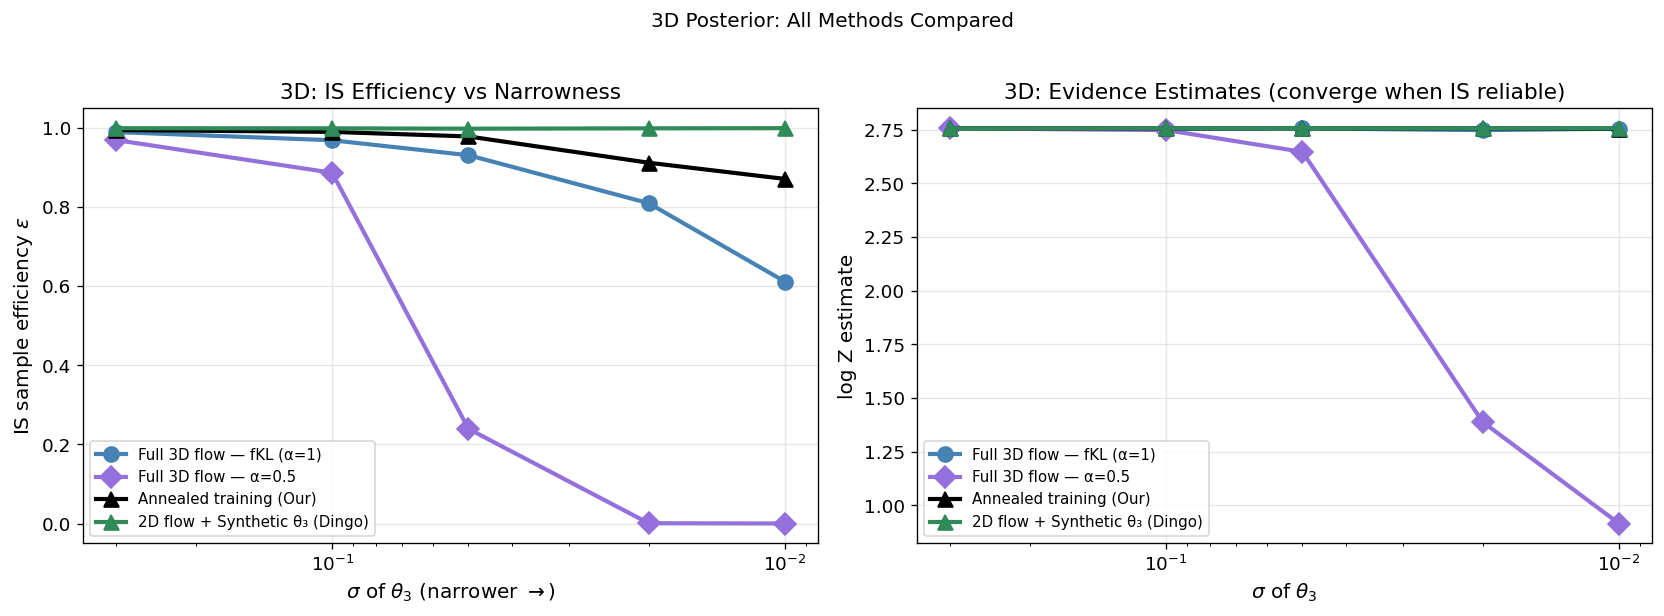

In [39]:
# ── Plot: 3D efficiency + evidence ────────────────────────────────────────────

methods_3d = [
    (results_3d_full,   'o-',  'steelblue',   'Full 3D flow — fKL (α=1)'),
    (results_3d_a05,    'D-',  'mediumpurple', 'Full 3D flow — α=0.5'),
    (results_3d_anneal, 'k^-', 'black',        'Annealed training (Our)'),
    (results_3d_synth,  '^-',  'seagreen',     '2D flow + Synthetic θ₃ (Dingo)'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: efficiency
ax = axes[0]
for res_list, marker, color, label in methods_3d:
    vals = [r['epsilon'] for r in res_list]
    ax.plot(sigmas_3d, vals, marker, color=color, lw=2.5, ms=9, label=label)
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel(r'$\sigma$ of $\theta_3$ (narrower $\rightarrow$)')
ax.set_ylabel(r'IS sample efficiency $\epsilon$')
ax.set_title('3D: IS Efficiency vs Narrowness')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: evidence
ax2 = axes[1]
for res_list, marker, color, label in methods_3d:
    vals = [r['logZ'] for r in res_list]
    ax2.plot(sigmas_3d, vals, marker, color=color, lw=2.5, ms=9, label=label)
ax2.set_xscale('log')
ax2.invert_xaxis()
ax2.set_xlabel(r'$\sigma$ of $\theta_3$')
ax2.set_ylabel('log Z estimate')
ax2.set_title('3D: Evidence Estimates (converge when IS reliable)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('3D Posterior: All Methods Compared', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('efficiency_3d_full.pdf', bbox_inches='tight')
plt.show()

## 10. Why synthetic marginalization works:

The Dingo trick can be understood as an exact **conditional factorization** of the proposal:

$$q(\theta_1, \theta_2) = \underbrace{q_{\text{flow}}(\theta_1)}_{\text{flow models this}} \cdot \underbrace{p(\theta_2 | \theta_1)}_{\text{exact conditional}}$$

The IS weight then becomes:

$$w = \frac{p(\theta_1) \cdot p(\theta_2|\theta_1)}{q_{\text{flow}}(\theta_1) \cdot p(\theta_2|\theta_1)} = \frac{p(\theta_1)}{q_{\text{flow}}(\theta_1)}$$

The narrow dimension **cancels exactly** from the IS weights. The efficiency is now determined solely by how well the flow models the broad marginal (a much easier task).

This is the key insight: **we only need the flow to model the dimensions it can model well**.

## 11. Summary

| Method | Mass-covering | Narrow dim $\epsilon$ | Requires $p(\theta_2\|\theta_1)$ known? |
|--------|-----------|----------------------------|----------------------------------------|
| Forward KL (NPE) | ✓ | Degrades as $\sigma \to 0$ (over-broadening) | ✗ |
| Reverse KL | ✗ | Degrades (mode-seeking) | ✗ |
| Synthetic marginalization | ✓ | **excellent, independent of $\sigma$** | ✓ |
| **Annealed training** (Our) | ✓ better than fKL and rKL | Degrades slightly | ✗ |